In [1]:
import ast
import pandas as pd
import anndata as ad
import numpy as np
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
from collections import defaultdict

In [ ]:
# plot appearance default parameters
mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family="Helvetica", size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=6)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=8)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

In [4]:
# functions
def combine_snps(row, columns=['snps', 'Position']):
    """
    Since we have SNPs from different sources and they are in different columns, we need to aggregate them
    Takes: row of the dataframe (therefore, it goes with .apply() function), column names with SNPs position
    Returns: a set of all SNPs positions per row (i.o. enhancer)
    """
    snps = set()
    for col in columns:
        if pd.notna(row[col]):
            for s in str(row[col]).split(','):
                snps.add(s.strip())
    return snps

def falls_into_reg(row, pos_dict):
    """
    Check if any SNPs from GWAS (saved in pos_dict as {chrom: [pos1, pos2, etc.]}) falls into given enhancer (row)
    Therefore, it goes with .apply() function
    """
    chrom = row['chr']
    positions = pos_dict.get(chrom, np.array([]))

    if len(positions) == 0:
        return None
    
    above_start = positions[positions >= row['start']]
    matches = above_start[above_start <= row['stop']]
    
    return ','.join(matches.astype(str)) if len(matches) > 0 else np.nan

def has_target_gene(gene_string, target_genes):
    if pd.isna(gene_string):
        return False
    genes = [g.strip() for g in str(gene_string).split(',')]
    return any(g in target_genes for g in genes)

In [5]:
# inputs 
adata = ad.read_h5ad('../data/Enhancers_AnnData.h5ad')

## GWAS from the Goovaerts et al. paper (i.o. leading SNPs)

In [11]:
gwas_df = pd.read_csv('../data/0_Goovaert_2026.csv', sep=';', header=0)
gwas_df.head(3)

,chr,pos_hg19,rs,p,neg_log_p,maf,n,a1,a2,genomic_locus,best_segment,primary_anatomical_region,other_anatomical_regions,other_snps_within_1mb,genes_great_distance_to_tss
0,1,978603,rs780665359,6.625200e-11,"10,1788","0,4387",48337,C,CCT,1,whole_craniofacial,Whole craniofacial region,Cranial vault,1,"AGRN (+23100), RNF223 (+31084)"
1,1,1687152,rs4648815,3.663500e-10,"9,4361","0,4754",48770,A,G,2,whole_craniofacial,Whole craniofacial region,Cranial vault,2,"SLC35E2 (-9721), NADK (+22757)"
2,1,2201744,rs77409011,2.423800e-12,"11,6155","0,0704",50593,T,G,3,whole_craniofacial,Whole craniofacial region,"Face, Lower face and midface, Nose, Upper face",5,"RER1 (-121528), SKI (+41610)"


In [ ]:
## getting a dataframe of observations with primate_specific+human_unique enhancers + all other enhancer related to the same genes

#preparing a set of target genes
gene_list_PS = adata.var.loc[
    adata.var['category'].isin(['primate_specific', 'human_unique']), 'gene'
].dropna().tolist()

target_genes = set()
for genes in gene_list_PS:
    for g in str(genes).split(','):
        g = g.strip()
        if g:
            target_genes.add(g)

In [ ]:
# fishing out enhancers related to target genes
enh_mask = adata.var['gene'].apply(has_target_gene)
adata_sub = adata[:, enh_mask].copy()

df_snp = adata_sub.var.loc[adata_sub.var['snps'].notna() | adata_sub.var['Position'].notna(), :].copy()

In [ ]:
# saving SNP data
# df_snp.to_csv('../output/3_1_SNPs_in_enhancers.tsv', index=False, sep='\t')
df_snp.to_excel('../output/3_1_SNPs_in_enhancers.xlsx', engine='xlsxwriter')

In [18]:
df_snp['all_snps'] = df_snp.apply(combine_snps, axis=1)
df_snp['N_snps'] = df_snp['all_snps'].apply(len)
df_snp

/tmp/ipykernel_2057956/946130009.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_snp['all_snps'] = df_snp.apply(combine_snps, axis=1)
/tmp/ipykernel_2057956/946130009.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_snp['N_snps'] = df_snp['all_snps'].apply(len)


,chr,start,stop,coord,enh_length,gene,name,Trait,Variation,Position,Vista_region,DAR_coarse,DAR_granular,DAR_regional,category,snps,all_snps,N_snps
index,,,,,,,,,,,,,,,,,,
COL6A1_COL6A2_en6,chr21,45357194,45358126,chr21-45357194-45358126,932,"COL6A1,COL6A2","14_EnhA2,13_EnhA1,15_EnhAF",blank,blank,45357937,NaN,"Mesenchyme A,Chondrogenic,Glia,Mesenchyme D (n...","anterior dermal fibroblast,dermal fibroblast,p...",NaN,other,NaN,{45357937},1
DLC1_en3,chr8,13045111,13046098,chr8-13045111-13046098,987,DLC1,"18_EnhAc,25_Quies",NaN,NaN,NaN,NaN,NaN,NaN,NaN,human_unique,13045567,{13045567},1
DLK1_MEG3_MEG8_en7,chr14,98069531,98070478,chr14-98069531-98070478,947,"DLK1,MEG3,MEG8","16_EnhW1,19_DNase,25_Quies",NaN,NaN,NaN,NaN,NaN,epithelia,NaN,other,98070450,{98070450},1
KIF26B_en20,chr1,245870425,245872534,chr1-245870425-245872534,2109,KIF26B,"14_EnhA2,18_EnhAc,15_EnhAF",earlobe attachment,Normal Variation,"245871189,245871320,245871752,245871816,245872190",NaN,"Mesenchyme F,Mesenchyme C (progenitor)","posterior mandibular mesenchyme,progenitors,an...",NaN,other,NaN,"{245872190, 245871320, 245871752, 245871189, 2...",5
LINC01572_ZFHX3_LINC01568_en1,chr16,72763772,72764863,chr16-72763772-72764863,1091,"LINC01572,ZFHX3,LINC01568","14_EnhA2,15_EnhAF",variation,Normal Variation,"72764234,72764388",NaN,Mesenchyme C (progenitor),"SOX11+ progenitor mesenchyme,posterior mandibu...",NaN,conservative,NaN,"{72764234, 72764388}",2
NFATC1_en4,chr18,79399912,79401064,chr18-79399912-79401064,1152,NFATC1,"2_PromU,22_PromP,14_EnhA2","12,blank, 12","Normal Variation,blank, Normal Variation","79400109,79400748",NaN,"Mesenchyme A,Chondrogenic,Neuronal,Osteogenic,...","anterior dermal fibroblast,chondrocyte 1,nasal...",nose,other,NaN,"{79400109, 79400748}",2
PRDM16_PRKCZ_SKI_en5,chr1,3334931,3335872,chr1-3334931-3335872,941,"PRDM16,PRKCZ,SKI","14_EnhA2,15_EnhAF,17_EnhW2,25_Quies","variation,blank, variation","Normal Variation, variation,blank, Normal Vari...","3335411,3335443",chr1:3334061-3336426,Chondrogenic,"chondrocyte 1,nasal chondrocyte,chondrocyte 2",nose,other,3335443,"{3335443, 3335411}",2
PRDM16_SKI_en2,chr1,3345596,3346525,chr1-3345596-3346525,929,"PRDM16,SKI","18_EnhAc,15_EnhAF,17_EnhW2",variation,variation,3345705,chr1:3345529-3349797,"Chondrogenic,Glia","chondrocyte 1,glia,nasal chondrocyte,chondrocy...",NaN,other,NaN,{3345705},1
SGCZ_en1,chr8,13043368,13044337,chr8-13043368-13044337,969,SGCZ,"14_EnhA2,15_EnhAF,18_EnhAc",NaN,NaN,NaN,NaN,Osteogenic,skeletal MPC,NaN,human_unique,13044154,{13044154},1


## GWAS extended (all SNPs)

We got a fuul SNPs database from Goovaerts after a meeting, so we expanded the data

### Preparing SNP coordinates

In [6]:
ex_gwas = pd.read_csv('../data/0_SNPs_extended.tsv', sep='\t', header=0, index_col=0)

In [10]:
mask = ex_gwas['p_value'] <= 1e-6
ex_gwas_filtered = ex_gwas[mask]
ex_gwas_filtered

,base_pair_location,effect_allele,other_allele,beta,standard_error,effect_allele_frequency,p_value,rsid,n
chromosome,,,,,,,,,
1,869121,T,TG,0,0,0.264704,1.658441e-07,rs548428268,48796
1,869303,C,T,0,0,0.742501,9.512617e-07,rs113171913,49643
1,871334,G,T,0,0,0.276178,1.068317e-07,rs4072383,50339
1,871683,G,A,0,0,0.263553,3.930067e-07,rs4504834,49582
1,872352,G,C,0,0,0.735341,5.688529e-08,rs1806780,50397
...,...,...,...,...,...,...,...,...,...
23,154925895,C,T,0,0,0.766033,2.300382e-12,rs538470,48306
23,154927581,G,A,0,0,0.696089,1.725838e-12,rs644138,50120
23,154929412,C,T,0,0,0.753594,1.368359e-13,rs557132,50425


In [11]:
# save .bed file with coordinates to lift over from hg19 to hg38
with open('../data/SNPs_hg19__extended.bed', 'w') as f:
    for i, row in ex_gwas_filtered.iterrows():
        pos = row['base_pair_location']
        pos_1 = int(row['base_pair_location']) + 1
        fourth_col = 'chr' + str(i) + ':' + str(pos)
        position_str = 'chr' + str(i) + '\t' + str(pos) + '\t' + str(pos_1) + '\t' + str(fourth_col) + '\n'
        f.writelines(position_str)

In [ ]:
# hg19 --> hg38 lift over

!/home/nadja/miniforge3/envs/internship_workflow/bin/liftOver -minMatch=0.9 '../data/SNPs_hg19__extended.bed' '../data/hg19Tohg38.over.chain.gz' '../data/0_hg38_p6_SNPs_extended.bed' '../data/0_unmapped_hg38_SNPs.bed' 

In [16]:
#processing liftOver results
snp_pos = pd.read_csv('../data/0_hg38_p6_SNPs_extended.bed', sep='\t', header=None, names=['pos_chr', 'pos_hg38', 'no_need', 'pos_hg19'])
snp_pos.drop(columns=['no_need', 'pos_hg19'], inplace=True)
snp_pos['pos_hg38'] = snp_pos['pos_hg38'].astype(int)
snp_pos

,pos_chr,pos_hg38
0,chr1,933741
1,chr1,933923
2,chr1,935954
3,chr1,936303
4,chr1,936972
...,...,...
380527,chr22,50673933
380528,chr22,50697167
380529,chr22,50698218
380530,chr22,50698666


In [17]:
# long: transformation the df to dict with arrays to increase speed 
pos_dict = defaultdict(list)
for _, row in snp_pos.iterrows():
    pos_dict[row['pos_chr']].append(row['pos_hg38'])

# making an array out of list to enhance the speed
pos_dict = {chrom: np.array(positions) for chrom, positions in pos_dict.items()}

### Overlaping enhancers with SNPs, aggregating all SNPs

In [18]:
# finding overlaps
adata.var[['start', 'stop']] = adata.var[['start', 'stop']].astype(int)

adata.var['snps_ext'] = adata.var.apply(falls_into_reg, axis=1, pos_dict=pos_dict)

In [19]:
# check 
print(f"Total number of enhancer regions: {adata.var.shape[0]}")
print(f"Number of enhancers containing SNPs: {adata.var['snps_ext'].notna().sum()}")

Total number of enhancer regions: 11748
Number of enhancers containing SNPs: 1511


In [20]:
# aggregating SNPs from all columns with SNPs positions
adata.var['all_snps'] = adata.var.apply(combine_snps, axis=1, columns=['snps', 'Position', 'snps_ext'])
adata.var['N_snps'] = adata.var['all_snps'].apply(len)
adata.var

,chr,start,stop,coord,enh_length,gene,name,Trait,Variation,Position,Vista_region,DAR_coarse,DAR_granular,DAR_regional,category,snps,snps_ext,all_snps,N_snps
index,,,,,,,,,,,,,,,,,,,
A2M_en1,chr12,6552777,6553565,chr12-6552777-6553565,788,A2M,12_TxEnhW,NaN,NaN,NaN,NaN,"Myoblast,Perivascular,Endothelia","myoblast,pericyte,endothelia",NaN,other,NaN,NaN,{},0
A2M_en2,chr12,6961626,6962570,chr12-6961626-6962570,944,A2M,13_EnhA1,NaN,NaN,NaN,NaN,"Chondrogenic,Perivascular,Blood,Epithelia","nasal chondrocyte,pericyte,erythrocytes,epithelia",NaN,other,NaN,NaN,{},0
AATK_EIF4A3_en1,chr17,81025157,81026152,chr17-81025157-81026152,995,"AATK,EIF4A3","19_DNase,15_EnhAF,17_EnhW2",NaN,NaN,NaN,NaN,"Mesenchyme A,Glia,Mesenchyme D (near-dermal),M...","anterior dermal fibroblast,glia,PAX9/PAX7+ nas...",nose,other,NaN,NaN,{},0
AATK_en1,chr17,80716905,80719152,chr17-80716905-80719152,2247,AATK,"25_Quies,17_EnhW2,8_TxWk",NaN,NaN,NaN,NaN,Glia,glia,NaN,primate_specific,NaN,NaN,{},0
AATK_en2,chr17,81314837,81315640,chr17-81314837-81315640,803,AATK,"15_EnhAF,17_EnhW2",NaN,NaN,NaN,NaN,Glia,glia,NaN,primate_specific,NaN,NaN,{},0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZZZ3_IFI44L_en1,chr1,76637075,76638127,chr1-76637075-76638127,1052,"ZZZ3,IFI44L","25_Quies,18_EnhAc",NaN,NaN,NaN,NaN,NaN,NaN,NaN,other,NaN,NaN,{},0
ZZZ3_IFI44L_en2,chr1,79657699,79658654,chr1-79657699-79658654,955,"ZZZ3,IFI44L","14_EnhA2,15_EnhAF,25_Quies",NaN,NaN,NaN,NaN,NaN,NaN,NaN,conservative,NaN,NaN,{},0
ZZZ3_en1,chr1,76278824,76279903,chr1-76278824-76279903,1079,ZZZ3,"14_EnhA2,8_TxWk",NaN,NaN,NaN,NaN,NaN,NaN,NaN,conservative,NaN,NaN,{},0


In [21]:
#check
(adata.var['N_snps'] != 0).sum()

np.int64(1584)

In [22]:
N_snps_dict = adata.var['N_snps'].value_counts().to_dict()
del N_snps_dict[0]
N_snps_dict

{1: 778,
 2: 387,
 3: 211,
 4: 108,
 5: 53,
 6: 24,
 7: 7,
 9: 6,
 8: 5,
 16: 2,
 11: 1,
 10: 1,
 18: 1}

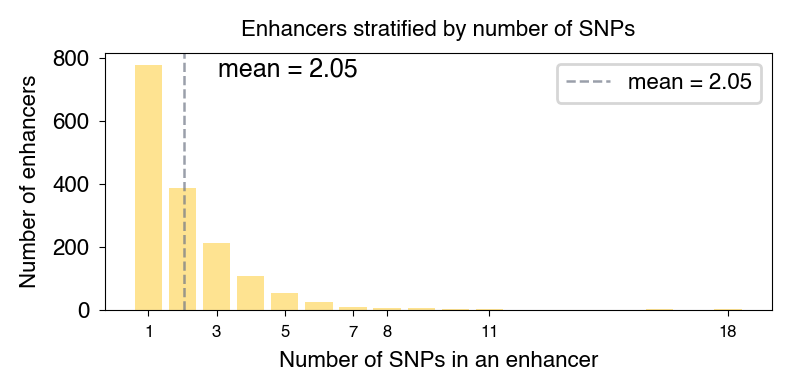

In [ ]:
# plot - enhancers stratified by number of SNPs
fig, ax = plt.subplots(figsize=(4, 2), dpi=200)

# convert to arrays once — used multiple times
x = np.array(list(N_snps_dict.keys()))
y = np.array(list(N_snps_dict.values()))

ax.bar(x, y, color='#FEE391')
ax.set_title("Enhancers stratified by number of SNPs")
ax.set_xlabel("Number of SNPs in an enhancer")
ax.set_ylabel("Number of enhancers")

# nicer x ticks
step = max(1, len(x) // 10 + 1)
ax.set_xticks(x[::step])

# weighted mean
mean_k = (x * y).sum() / y.sum() if y.sum() > 0 else np.nan
if np.isfinite(mean_k):
    ax.axvline(mean_k, linestyle="--", linewidth=0.9, alpha=0.7, color='#707786', label=f"mean = {mean_k:.2f}")
    ax.text(mean_k + 1, ax.get_ylim()[1] * 0.98, f"mean = {mean_k:.2f}",
            ha="left", va="top", fontsize=9)

ax.legend()
fig.tight_layout()
plt.show()

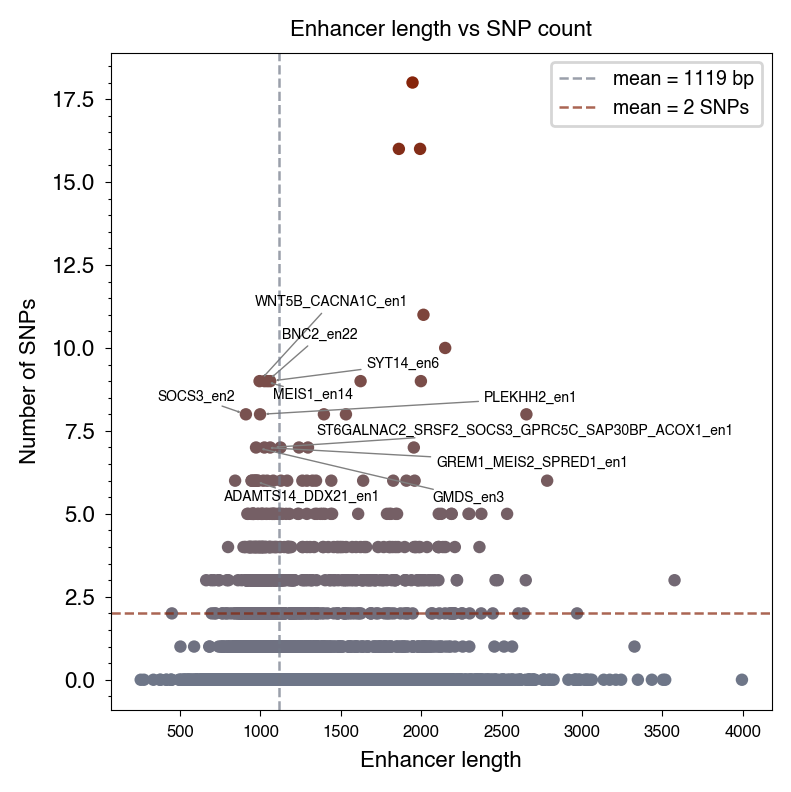

In [ ]:
# exploratory plot to see the deppendence between number of SNPs and enhancer length
fig, ax = plt.subplots(figsize=(4, 4), dpi=200)

custom_div = mpl.colors.LinearSegmentedColormap.from_list("custom_div", ["#6E7688", "#86240A"])

x = adata.var['enh_length'].to_numpy()
y = adata.var['N_snps'].to_numpy().astype(int)
length_mean = x.mean()
snp_mean = 2.01

sns.scatterplot(
    data=adata.var,
    x=x, y=y,
    hue=y,
    palette=custom_div,
    ax=ax, s=20,
    linewidth=0, edgecolor=None,
    legend=False,
)

# mean lines
ax.axvline(length_mean, linestyle="--", linewidth=0.9, alpha=0.7, color='#707786', label=f"mean = {length_mean:.0f} bp")
ax.axhline(snp_mean, linestyle="--", linewidth=0.9, alpha=0.7, color='#86240A', label=f"mean = {snp_mean:.0f} SNPs")

# top 10 short enhancers with most SNPs
top = adata.var[adata.var['enh_length'] < length_mean].nlargest(10, 'N_snps')
texts = []
for name, row in top.iterrows():
    texts.append(ax.text(row['enh_length'], row['N_snps'], name, fontsize=5, color="black"))
adjust_text(texts, ax=ax, expand=(1.3, 2),
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))

# y ticks


# legends, labels
ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
ax.set_xlabel("Enhancer length")
ax.set_ylabel("Number of SNPs")
ax.set_title("Enhancer length vs SNP count")
ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

In [25]:
#save adata
filename = '../data/Enhancers_AnnData.h5ad'
adata.var['all_snps'] = adata.var['all_snps'].astype(str)
adata.write_h5ad(filename)

### SNPs in enhancers of interest (primate-specific, human-specific)

In [10]:
# fishing out
enh_mask = adata.var['gene'].apply(has_target_gene, target_genes=target_genes)
adata_sub = adata[:, enh_mask].copy()

df = adata_sub.var # dataframe with target genes
df_snp = df.loc[df['N_snps'] != 0, :]

/tmp/ipykernel_1830605/1000816692.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_snp.groupby('category')['N_snps'].sum()


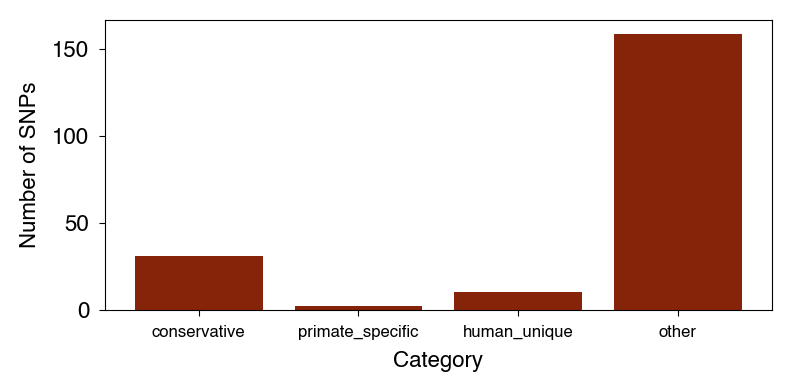

In [ ]:
# bar plot of SNPs falling in enhancer categories
fig, ax = plt.subplots(figsize=(4,2), dpi=200)
counts = df_snp.groupby('category')['N_snps'].sum()
ax.bar(x=counts.index, height=counts.values, color='#86240A')
ax.set_xlabel('Category')
ax.set_ylabel('Number of SNPs')
plt.tight_layout()

In [37]:
df_snp.to_excel('../output/3_1_SNPs_ext_in_enhancers.xlsx', engine='xlsxwriter')

df_target_enh = df_snp.loc[df_snp['category'].isin(['primate_specific', 'human_unique']), ]
df_target_enh.to_excel('../output/3_1_SNPs_ext_target_enhancers.xlsx', engine='xlsxwriter')

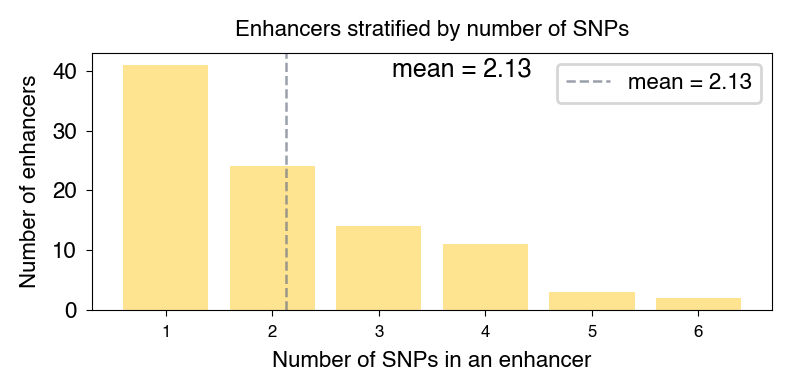

In [ ]:
# checking a mean value within this group of enhancers
fig, ax = plt.subplots(figsize=(4, 2), dpi=200)

# convert to arrays once — used multiple times
x = np.array(list(N_snps_dict.keys()))
y = np.array(list(N_snps_dict.values()))

ax.bar(x, y, color='#FEE391')
ax.set_title("Enhancers stratified by number of SNPs")
ax.set_xlabel("Number of SNPs in an enhancer")
ax.set_ylabel("Number of enhancers")

# nicer x ticks
step = max(1, len(x) // 10 + 1)
ax.set_xticks(x[::step])

# weighted mean
mean_k = (x * y).sum() / y.sum() if y.sum() > 0 else np.nan
if np.isfinite(mean_k):
    ax.axvline(mean_k, linestyle="--", linewidth=0.9, alpha=0.7, color='#707786', label=f"mean = {mean_k:.2f}")
    ax.text(mean_k + 1, ax.get_ylim()[1] * 0.98, f"mean = {mean_k:.2f}",
            ha="left", va="top", fontsize=9)

ax.legend()
fig.tight_layout()
plt.show()

### SNPs info for human unique enhancers

In [ ]:
# snps positions
snp_pos = pd.read_csv('../data/0_hg38_p6_SNPs_extended.bed', sep='\t', header=None,
                      names=['pos_chr', 'pos_hg38', 'pos_hg38_end', 'pos_hg19_raw'])

snp_pos = snp_pos.drop(columns=['pos_hg38_end'])
snp_pos['pos_chr'] = snp_pos['pos_chr'].str.removeprefix('chr').astype(int)
snp_pos['pos_hg38'] = snp_pos['pos_hg38'].astype(int)
snp_pos[['hg19_chr', 'pos_hg19']] = snp_pos['pos_hg19_raw'].str.split(':', expand=True)
snp_pos['hg19_chr'] = snp_pos['hg19_chr'].str.removeprefix('chr').astype(int)
snp_pos['pos_hg19'] = snp_pos['pos_hg19'].astype(int)
snp_pos = snp_pos.drop(columns=['pos_hg19_raw'])

# attach GWAS info via hg19 coordinates
snp_gwas = snp_pos.merge(ex_gwas.reset_index(),
                          left_on=['hg19_chr', 'pos_hg19'],
                          right_on=['chromosome', 'base_pair_location'],
                          how='left')

In [88]:
df_enh = df_target_enh.reset_index()[['index', 'chr', 'category', 'all_snps']].copy()
df_enh = df_enh.rename(columns={'index': 'enhancer'})
df_enh['chr'] = df_enh['chr'].str.removeprefix('chr').astype(int)
df_enh['all_snps'] = df_enh['all_snps'].astype(object).apply(lambda x: [int(i) for i in ast.literal_eval(x)])
df_enh = df_enh.explode('all_snps')
df_enh['all_snps'] = df_enh['all_snps'].astype(int)

snp_info = df_enh.merge(snp_gwas,
                        left_on=['chr', 'all_snps'],
                        right_on=['pos_chr', 'pos_hg38'],
                        how='left')
snp_info

,enhancer,chr,category,all_snps,pos_chr,pos_hg38,hg19_chr,pos_hg19,chromosome,base_pair_location,effect_allele,other_allele,beta,standard_error,effect_allele_frequency,p_value,rsid,n
0,CKB_en3,14,primate_specific,103549729,14,103549729,14,104016066,14,104016066,C,T,0,0,0.772679,7.199461e-09,rs11626905,50244
1,CYTL1_STK32B_en1,4,primate_specific,7961501,4,7961501,4,7963228,4,7963228,G,C,0,0,0.570908,6.820245e-08,rs11726359,50234
2,DLC1_en3,8,human_unique,13046085,8,13046085,8,12903594,8,12903594,C,A,0,0,0.602499,3.726490e-11,rs505902,49303
3,DLC1_en3,8,human_unique,13045984,8,13045984,8,12903493,8,12903493,G,A,0,0,0.602910,2.242849e-11,rs483677,49252
4,DLC1_en3,8,human_unique,13045567,8,13045567,8,12903076,8,12903076,T,A,0,0,0.602436,1.066105e-11,rs479247,49265
5,DLC1_en3,8,human_unique,13045684,8,13045684,8,12903193,8,12903193,T,C,0,0,0.075516,1.057791e-11,rs612725,50473
6,DLC1_en3,8,human_unique,13045977,8,13045977,8,12903486,8,12903486,A,G,0,0,0.603029,1.613615e-11,rs483067,49253
7,DLC1_en3,8,human_unique,13045143,8,13045143,8,12902652,8,12902652,C,T,0,0,0.602450,3.154278e-11,rs578248,49190
8,SGCZ_en1,8,human_unique,13043738,8,13043738,8,12901247,8,12901247,A,G,0,0,0.076951,3.453027e-12,rs544302,50662
9,SGCZ_en1,8,human_unique,13044154,8,13044154,8,12901663,8,12901663,T,A,0,0,0.076704,2.024883e-12,rs547998,50630


In [90]:
snp_info.to_excel('../output/3_1_SNPs_from_PS_HU.xlsx', engine='xlsxwriter')